In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [6]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [7]:
import os

os.listdir()

['.config', 'archive (1).zip', 'sample_data']

In [10]:
import zipfile

with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Done")

Done


In [11]:
import os

os.listdir()

['.config', 'archive (1).zip', 'spam.csv', 'sample_data']

In [12]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding="latin-1")

In [13]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
print(df.head())
print(df.shape)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
(5572, 2)


In [15]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


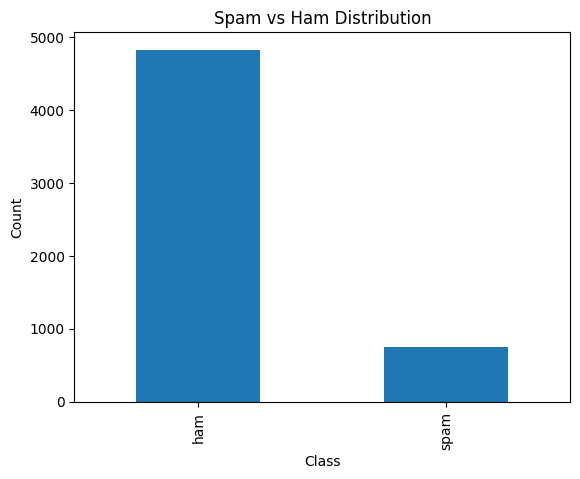

In [16]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title("Spam vs Ham Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [17]:
df.isnull().sum()

,0
label,0
message,0


In [18]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

In [19]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [20]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [21]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [22]:
def clean_text(text):

    text = str(text).lower()

    words = text.split()

    filtered_words = []

    for word in words:
        if word not in stop_words:
            filtered_words.append(word)

    return " ".join(filtered_words)

In [23]:
df['message'] = df['message'].apply(clean_text)

In [24]:
df.head()

,label,message
0,0,"go jurong point, crazy.. available bugis n gre..."
1,0,ok lar... joking wif u oni...
2,1,free entry 2 wkly comp win fa cup final tkts 2...
3,0,u dun say early hor... u c already say...
4,0,"nah think goes usf, lives around though"


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

In [26]:
X = tfidf.fit_transform(df['message'])

y = df['label']

In [27]:
print(X.shape)

(5572, 8650)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [30]:
predictions = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.9713004484304932


In [32]:
print("Accuracy:", accuracy)

Accuracy: 0.9713004484304932


In [33]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       1.00      0.79      0.88       150

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[965   0]
 [ 32 118]]


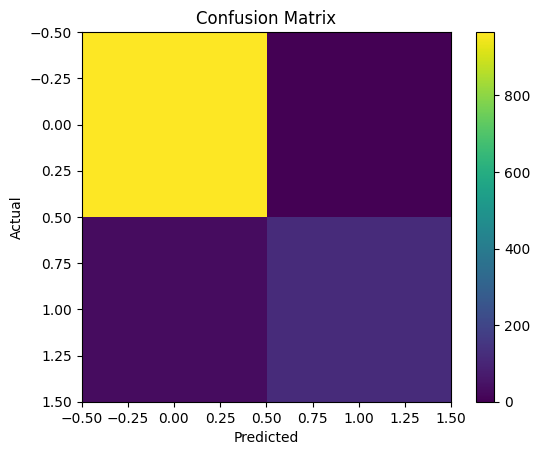

In [35]:
import matplotlib.pyplot as plt

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [36]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(
    X_train,
    y_train
)

LogisticRegression()

In [37]:
lr_predictions = lr_model.predict(X_test)

In [38]:
lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9488789237668162


In [39]:
print("Naive Bayes Accuracy :", accuracy)
print("Logistic Regression Accuracy :", lr_accuracy)

Naive Bayes Accuracy : 0.9713004484304932
Logistic Regression Accuracy : 0.9488789237668162


In [40]:
email = [
    "Congratulations! You have won a free iPhone. Click here now."
]

vector = tfidf.transform(email)

prediction = model.predict(vector)

print(prediction)

[0]


In [41]:
email = [
    "Hey bro, are we meeting tomorrow at 5 PM?"
]

vector = tfidf.transform(email)

prediction = model.predict(vector)

print(prediction)

[0]


In [42]:
import pickle

pickle.dump(
    model,
    open("spam_model.pkl","wb")
)

pickle.dump(
    tfidf,
    open("vectorizer.pkl","wb")
)

In [43]:
import os

os.listdir()

['.config',
 'archive (1).zip',
 'vectorizer.pkl',
 'spam_model.pkl',
 'spam.csv',
 'sample_data']

In [44]:
from google.colab import files

files.download("spam_model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import zipfile

with zipfile.ZipFile('archive (1) (3).zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Extraction Complete!")

FileNotFoundError: [Errno 2] No such file or directory: 'archive (1) (3).zip'

# Spam Email Detection using Machine Learning

## Objective
Build a machine learning model that classifies messages as Spam or Ham.

## Dataset
SMS Spam Collection Dataset

## Techniques Used
- Data Cleaning
- Stopword Removal
- TF-IDF Vectorization
- Multinomial Naive Bayes
- Logistic Regression

## Results
- Naive Bayes Accuracy: 97.13%
- Dataset Size: 5572 messages

## Libraries
- Pandas
- Numpy
- NLTK
- Scikit-learn
- Matplotlib

In [9]:
import os

os.listdir()

['.config', 'archive (1).zip', 'sample_data']

In [4]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding="latin-1")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'spam.csv'

In [14]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [15]:
df = df[['v1', 'v2']]

df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [17]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747
